In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imputation Modules
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Machine Learning Modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
df_clean

,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,savings_to_income_ratio,region,is_good_credit
0,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,8.68,Other,0
1,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,6.16,North America,0
2,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,6.87,Africa,1
3,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,4.31,Europe,0
4,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,7.50,Africa,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32419,30,Female,High School,Employed,Salesperson,4266.87,1510.82,273669.70,Yes,Car,498400.74,120,6227.54,8.68,1.46,5.34,Europe,0
32420,51,Female,Master,Employed,Student,5725.78,4965.02,17247.57,Yes,Home,83602.57,12,7605.13,16.50,1.33,0.25,North America,0
32421,18,Female,Bachelor,Self-employed,Doctor,3282.38,2243.77,22081.21,No,NaN,0.00,0,0.00,0.00,0.00,0.56,Other,0
32422,36,Other,High School,Self-employed,Accountant,5035.99,4054.32,524039.88,No,NaN,0.00,0,0.00,0.00,0.00,8.67,Asia,0


=== Class Distribution (is_good_credit) ===
is_good_credit
0    63.39%
1    36.61%
Name: proportion, dtype: str

1. Data Prepared. Targets for Missing Injection: ['education_level', 'employment_status', 'monthly_income_usd', 'age', 'job_title']
2. Train/Test Split Completed. Test data safely isolated.

--------------------------------------------------
🔄 Processing Missing Rate: 10%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 20%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 30%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 40%
--------------------------------------------------

--------------------------------------------------
🔄 Processing Missing Rate: 50%
--------------------------------------------------

=== Downstream ML Performa

Missing Rate                                            10%     20%     30%  \
ML Model            Dataset Version                                           
Logistic Regression 1. Ground Truth (No Missing)     0.4349  0.4349  0.4349   
                    2. Simple Imputed (Mode/Median)  0.4285  0.4111  0.4051   
                    3. KNN Imputed                   0.4279  0.4081  0.4093   
                    4. Iterative Imputed             0.4166  0.3896  0.3743   
Naive Bayes         1. Ground Truth (No Missing)     0.0833  0.0833  0.0833   
                    2. Simple Imputed (Mode/Median)  0.0901  0.1096  0.1258   
                    3. KNN Imputed                   0.0689  0.1113  0.0983   
                    4. Iterative Imputed             0.0905  0.1106  0.1198   
Random Forest       1. Ground Truth (No Missing)     0.0818  0.0818  0.0818   
                    2. Simple Imputed (Mode/Median)  0.0723  0.0657  0.0914   
                    3. KNN Imputed                   0.0759  0.0677  0.0742   
                    4. Iterative Imputed             0.0615  0.0684  0.0651   

Missing Rate                                            40%     50%  
ML Model            Dataset Version                                  
Logistic Regression 1. Ground Truth (No Missing)     0.4349  0.4349  
                    2. Simple Imputed (Mode/Median)  0.4067  0.4078  
                    3. KNN Imputed                   0.4435  0.4349  
                    4. Iterative Imputed             0.3857  0.4275  
Naive Bayes         1. Ground Truth (No Missing)     0.0833  0.0833  
                    2. Simple Imputed (Mode/Median)  0.1571  0.2340  
                    3. KNN Imputed                   0.1122  0.2552  
                    4. Iterative Imputed             0.1490  0.2421  
Random Forest       1. Ground Truth (No Missing)     0.0818  0.0818  
                    2. Simple Imputed (Mode/Median)  0.0776  0.0784  
                    3. KNN Imputed                   0.0798  0.0863  
                    4. Iterative Imputed             0.0619  0.0753

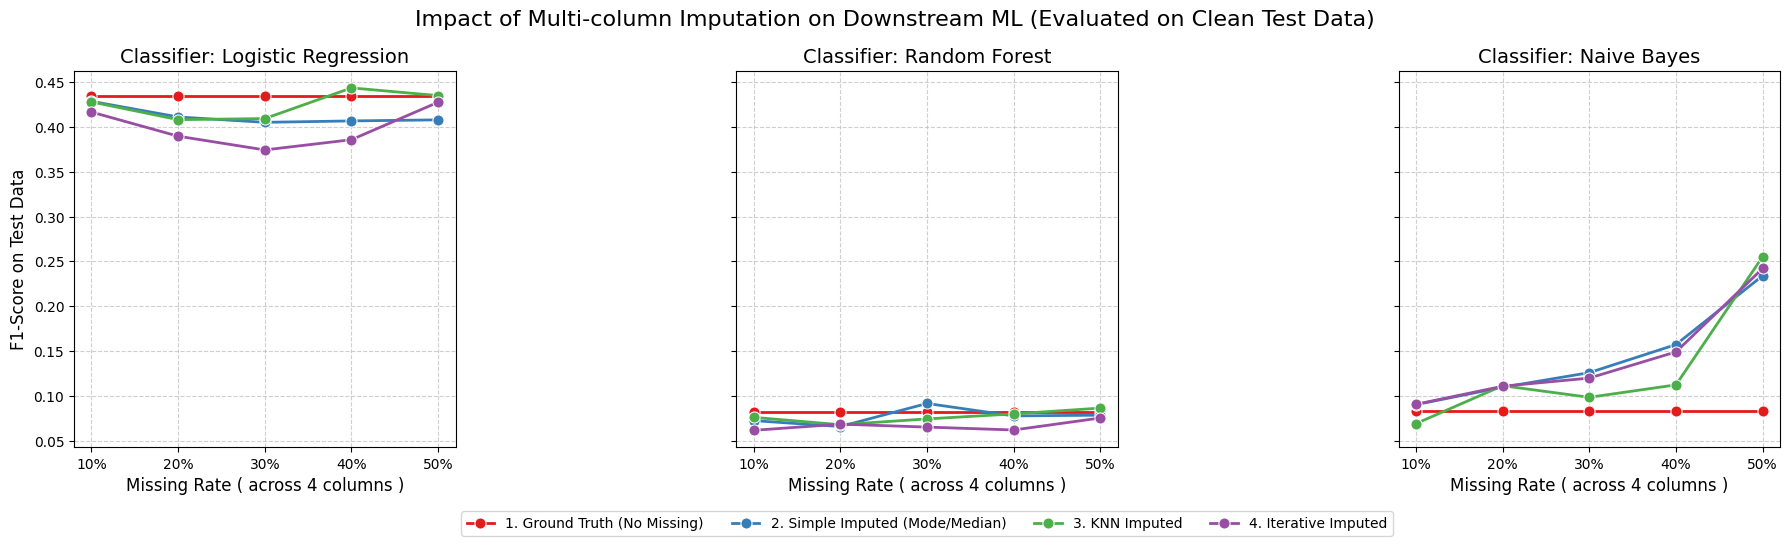

In [ ]:
# ==========================================
# 1. Collect Data & Clean Data
# ==========================================
df = pd.read_csv('data/synthetic_personal_finance_dataset.csv')

# ตัดคอลัมน์ที่ไม่จำเป็น
df_clean = df.drop(columns=['user_id', 'record_date']).copy()

# สร้าง Downstream Target
df_clean['is_good_credit'] = (df_clean['credit_score'] >= 650).astype(int)

print("=== Class Distribution (is_good_credit) ===")
print(df_clean['is_good_credit'].value_counts(normalize=True).apply(lambda x: f"{x:.2%}"))
print("===========================================\n")

# ตัด credit_score เดิมทิ้ง
df_clean = df_clean.drop(columns=['credit_score'])

impute_targets = ['education_level', 'employment_status', 'monthly_income_usd', 'age', 'job_title']
missing_rates = [0.1, 0.2, 0.3, 0.4, 0.5] 

print(f"1. Data Prepared. Targets for Missing Injection: {impute_targets}")

# ==========================================
# 2. Train / Test Split (Prevent Data Leakage)
# ==========================================
# แยก Features และ Target
X_full = df_clean.drop(columns=['is_good_credit'])
y_full = df_clean['is_good_credit']

# หั่นข้อมูล: X_test_clean จะถูกเก็บไว้เป็น Ground Truth สำหรับวัดผลตอนจบ
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print("2. Train/Test Split Completed. Test data safely isolated.")

# ==========================================
# เตรียม Label Encoder จากข้อมูลทั้งหมด (เพื่อครอบคลุมทุกหมวดหมู่ที่เป็นไปได้)
# ==========================================
le_dict = {}
cat_cols = X_train_clean.select_dtypes(include=['object', 'string']).columns
num_cols = X_train_clean.select_dtypes(include=np.number).columns

for col in cat_cols:
    le = LabelEncoder()
    # Fit เผื่อคลาส Missing เข้าไปด้วย เพื่อความปลอดภัยตอน Transform
    all_possible_vals = df_clean[col].dropna().astype(str).unique().tolist()
    le.fit(all_possible_vals + ['Missing_Fallback']) 
    le_dict[col] = le

# กำหนด ML Models
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Naive Bayes': GaussianNB() 
}

results = []

# ==========================================
# 3. เริ่ม Loop ทดสอบทีละ Missing Rate บน Train Data
# ==========================================
for rate in missing_rates:
    rate_str = f"{int(rate*100)}%"
    print(f"\n{'-'*50}")
    print(f"🔄 Processing Missing Rate: {rate_str}")
    print(f"{'-'*50}")
    
    # --- 3.1 Missing Injection (เฉพาะ Train Data) ---
    np.random.seed(42)
    X_train_sim = X_train_clean.copy()
    
    for col in impute_targets:
        n_missing = int(len(X_train_sim) * rate)
        missing_indices = np.random.choice(X_train_sim.index, n_missing, replace=False)
        X_train_sim.loc[missing_indices, col] = np.nan

    # --- 3.2 Impute Data (คำนวณสถิติจาก Train Data เท่านั้น) ---
    X_train_for_impute = X_train_sim.copy()

    # Encode Categorical -> Float ก่อนเข้า Imputer
    for col in cat_cols:
        not_null_mask = X_train_for_impute[col].notnull()
        encoded_col = pd.Series(np.nan, index=X_train_for_impute.index, dtype=float)
        encoded_col.loc[not_null_mask] = le_dict[col].transform(X_train_for_impute.loc[not_null_mask, col].astype(str))
        X_train_for_impute[col] = encoded_col

    # Scale ALL columns ก่อนทำ Imputation
    scaler_impute = StandardScaler()
    col_names = X_train_for_impute.columns
    X_train_for_impute_scaled = pd.DataFrame(
        scaler_impute.fit_transform(X_train_for_impute), 
        columns=col_names, 
        index=X_train_for_impute.index
    )

    # 1. Simple Imputed (Mode/Median)
    X_train_simple = X_train_sim.copy()
    for col in impute_targets:
        if col in cat_cols:
            mode_val = X_train_simple[col].mode()[0]
            X_train_simple[col] = X_train_simple[col].fillna(mode_val)
        else:
            median_val = X_train_simple[col].median()
            X_train_simple[col] = X_train_simple[col].fillna(median_val)

    # 2. KNN Imputed
    knn_imputer = KNNImputer(n_neighbors=5)
    X_knn_scaled = pd.DataFrame(knn_imputer.fit_transform(X_train_for_impute_scaled), columns=col_names, index=X_train_for_impute.index)
    X_knn_num = pd.DataFrame(scaler_impute.inverse_transform(X_knn_scaled), columns=col_names, index=X_train_for_impute.index)

    # 3. Iterative Imputed
    iter_imputer = IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10)
    X_iter_scaled = pd.DataFrame(iter_imputer.fit_transform(X_train_for_impute_scaled), columns=col_names, index=X_train_for_impute.index)
    X_iter_num = pd.DataFrame(scaler_impute.inverse_transform(X_iter_scaled), columns=col_names, index=X_train_for_impute.index)

    # --- นำค่าที่ซ่อมแล้ว ประกอบร่างกลับคืน ---
    X_train_knn = X_train_sim.copy()
    X_train_iter = X_train_sim.copy()
    
    for col in impute_targets:
        missing_mask = X_train_sim[col].isnull()
        
        if col in cat_cols:
            imputed_knn_vals = np.round(X_knn_num.loc[missing_mask, col]).astype(int)
            imputed_knn_vals = np.clip(imputed_knn_vals, 0, len(le_dict[col].classes_) - 1)
            X_train_knn.loc[missing_mask, col] = le_dict[col].inverse_transform(imputed_knn_vals)
            
            imputed_iter_vals = np.round(X_iter_num.loc[missing_mask, col]).astype(int)
            imputed_iter_vals = np.clip(imputed_iter_vals, 0, len(le_dict[col].classes_) - 1)
            X_train_iter.loc[missing_mask, col] = le_dict[col].inverse_transform(imputed_iter_vals)
        else:
            X_train_knn.loc[missing_mask, col] = X_knn_num.loc[missing_mask, col]
            X_train_iter.loc[missing_mask, col] = X_iter_num.loc[missing_mask, col]

    train_datasets = {
        '1. Ground Truth (No Missing)': X_train_clean,
        '2. Simple Imputed (Mode/Median)': X_train_simple,
        '3. KNN Imputed': X_train_knn,
        '4. Iterative Imputed': X_train_iter
    }

    # ==========================================
    # 4 & 5. Evaluate with ML Models
    # ==========================================
    for data_name, X_train_data in train_datasets.items():
        
        # One-Hot Encoding
        X_train_ohe = pd.get_dummies(X_train_data, drop_first=True)
        # เราต้อง OHE Test Data ด้วย 
        X_test_ohe = pd.get_dummies(X_test_clean, drop_first=True)
        
        # Align Test columns ให้ตรงกับ Train columns เผื่อมีบาง Category ขาดหายไป
        X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)
        
        # StandardScaler สำหรับ Machine Learning 
        # (Fit บน Train ที่ผ่านการ OHE แล้ว และ Transform บน Test)
        scaler_ml = StandardScaler()
        X_train_final = scaler_ml.fit_transform(X_train_ohe)
        X_test_final = scaler_ml.transform(X_test_ohe)
        
        for model_name, model in ml_models.items():
            # 💡 Train Model บน "Training Data ที่ถูก Impute แล้ว"
            model.fit(X_train_final, y_train)
            
            # 💡 Predict และ Evaluate บน "Test Data ที่สมบูรณ์และบริสุทธิ์ 100%"
            y_pred = model.predict(X_test_final)
            
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            
            results.append({
                'Missing Rate': rate_str,
                'Dataset Version': data_name,
                'ML Model': model_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1
            })

# ==========================================
# 6. สรุปผลลัพธ์และพล็อตจุดกราฟ (Plotting)
# ==========================================
df_results = pd.DataFrame(results)

print("\n=== Downstream ML Performance Comparison (F1-Score) ===")
pivot_f1 = df_results.pivot_table(
    index=['ML Model', 'Dataset Version'], 
    columns='Missing Rate', 
    values='F1-Score'
)
display(pivot_f1.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Impact of Multi-column Imputation on Downstream ML (Evaluated on Clean Test Data)', fontsize=16)

for i, model_name in enumerate(ml_models.keys()):
    sns.lineplot(
        data=df_results[df_results['ML Model'] == model_name],
        x='Missing Rate', 
        y='F1-Score', 
        hue='Dataset Version', 
        marker='o', 
        linewidth=2,
        markersize=8,
        ax=axes[i], 
        palette='Set1'
    )
    axes[i].set_title(f'Classifier: {model_name}', fontsize=14)
    axes[i].set_xlabel('Missing Rate ( across 4 columns )', fontsize=12)
    axes[i].set_ylabel('F1-Score on Test Data', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    
    if i == 1:
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()